In [8]:
import pandas as pd
bsse_data = pd.read_csv("BSSE_by_FF_distance.csv")

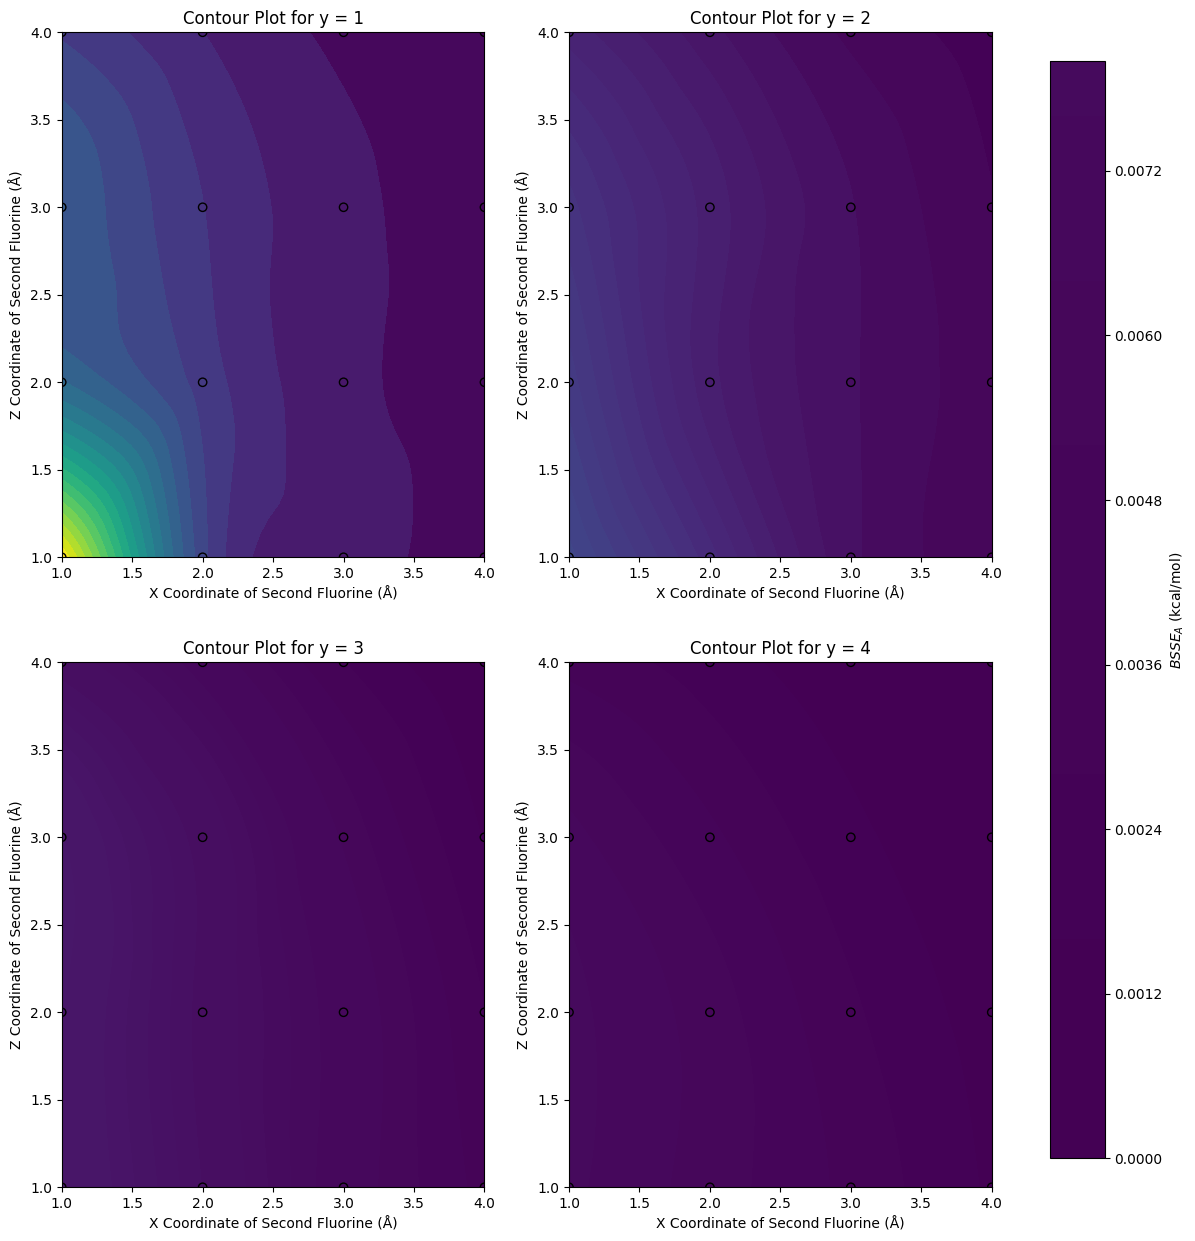

In [73]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

fig, axes = plt.subplots(2, 2, figsize=(15, 15))

# Store all BSSE values across plots for consistent color scale
all_bsse = []

# First pass: gather global min/max for color normalization
for fixed_y_value in [1, 2, 3, 4]:
    data = bsse_data[bsse_data['y'] == fixed_y_value]
    all_bsse.extend(data['BSSE_A'].values * 627.5096)

vmin = min(all_bsse)
vmax = max(all_bsse)

# Second pass: plotting
for i, fixed_y_value in enumerate([1, 2, 3, 4]):
    ax = axes[i // 2, i % 2]

    data = bsse_data[bsse_data['y'] == fixed_y_value][['x', 'z', 'BSSE_A']]
    xs = data['x'].values
    zs = data['z'].values
    bsse = data['BSSE_A'].values * 627.5096

    # Grid and interpolation
    xi = np.linspace(min(xs), max(xs), 50)
    zi = np.linspace(min(zs), max(zs), 50)
    Xi, Zi = np.meshgrid(xi, zi)
    bssei = griddata((xs, zs), bsse, (Xi, Zi), method='cubic')

    # Filled contour plot with fixed vmin/vmax
    contour = ax.contourf(Xi, Zi, bssei, levels=20, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.scatter(xs, zs, c=bsse, cmap='viridis', vmin=vmin, vmax=vmax, edgecolor='k')

    ax.set_title(f'Contour Plot for y = {fixed_y_value}')
    ax.set_xlabel('X Coordinate of Second Fluorine (Å)')
    ax.set_ylabel('Z Coordinate of Second Fluorine (Å)')

# Shared colorbar
fig.colorbar(contour, ax=axes.ravel(), label='$BSSE_{A}$ (kcal/mol)', shrink=0.95)

plt.show()


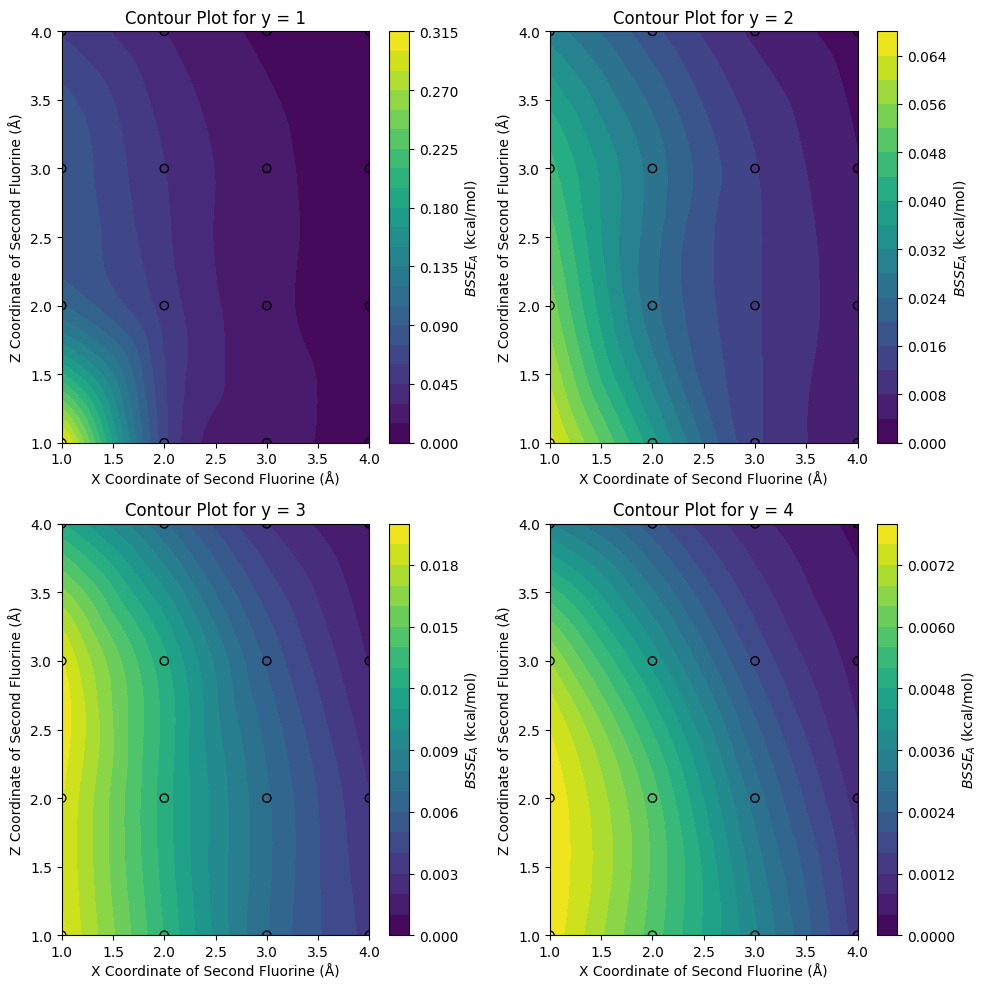

In [70]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for i, fixed_y_value in enumerate([1, 2, 3, 4]):
    ax = axes[i // 2, i % 2]
    
    data_for_contour_plot = bsse_data[bsse_data['y'] == fixed_y_value][['x', 'z', 'BSSE_A']]
    
    xs = data_for_contour_plot['x'].values
    zs = data_for_contour_plot['z'].values
    bsse = data_for_contour_plot['BSSE_A'].values * 627.5096

    # Create grid
    xi = np.linspace(min(xs), max(xs), 50)
    zi = np.linspace(min(zs), max(zs), 50)
    Xi, Zi = np.meshgrid(xi, zi)

    # Interpolate
    bssei = griddata((xs, zs), bsse, (Xi, Zi), method='cubic')

    # Plot
    contour = ax.contourf(Xi, Zi, bssei, levels=20, cmap='viridis')
    scatter = ax.scatter(xs, zs, c=bsse, cmap='viridis', edgecolor='k')

    # Colorbar
    fig.colorbar(contour, ax=ax, label='$BSSE_{A}$ (kcal/mol)')

    # Labels and title
    ax.set_title(f'Contour Plot for y = {fixed_y_value}')
    ax.set_xlabel('X Coordinate of Second Fluorine (Å)')
    ax.set_ylabel('Z Coordinate of Second Fluorine (Å)')

plt.tight_layout()
plt.show()
